In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

data_path = "/Users/niraj/Downloads/ml_files/datasets/SC2_Compiled.csv"
df = pd.read_csv(data_path)
df = df.drop(columns=['Sample_no', 'RSN', 
                      'IA', 
                      'Dsig_(sec)','T2_(s)', 'T3_(s)',
                      'Final_T1 (s)', 'Final_T2 (s)', 'Final_T3 (s)', 
                      'max_base_shear_kN',
                      'MIDR_1st_floor', 'MIDR_2nd_floor', 'MIDR_3rd_floor', 'MIDR_4th_floor',
                      'Max_Park_Ang_DI_storey', 'Park_Ang_DI'])

X = df.iloc[:, :24]
y = df.iloc[:, 24]

In [2]:
print(df.info())
print(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54376 entries, 0 to 54375
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fc_(MPa)        54376 non-null  int64  
 1   fy_(MPa)        54376 non-null  int64  
 2   Ab_(m2)         54376 non-null  float64
 3   Ac_(m2)         54376 non-null  float64
 4   Lx_(m)          54376 non-null  float64
 5   Ly_(m)          54376 non-null  float64
 6   Lz_(m)          54376 non-null  float64
 7   Nx              54376 non-null  int64  
 8   Ny              54376 non-null  int64  
 9   Nz              54376 non-null  int64  
 10  Ap_(m2)         54376 non-null  float64
 11  AR              54376 non-null  float64
 12  Kfc             54376 non-null  float64
 13  ρ               54376 non-null  float64
 14  Tm_(sec)        54376 non-null  float64
 15  PGA_(g)         54376 non-null  float64
 16  PGV_(cm/sec)    54376 non-null  float64
 17  PGV/PGA_(sec)   54376 non-null 

In [3]:
print("Target Variable Summary:")
print(f"Mean: {y.mean():.4f}")
print(f"Std: {y.std():.4f}")
print(f"Variance: {y.var():.4f}")
print(f"Min: {y.min():.4f}")
print(f"Max: {y.max():.4f}")
print(f"IQR: {y.quantile(0.75) - y.quantile(0.25):.4f}")

Target Variable Summary:
Mean: 2.3594
Std: 1.8478
Variance: 3.4144
Min: 0.0130
Max: 13.5330
IQR: 1.8630


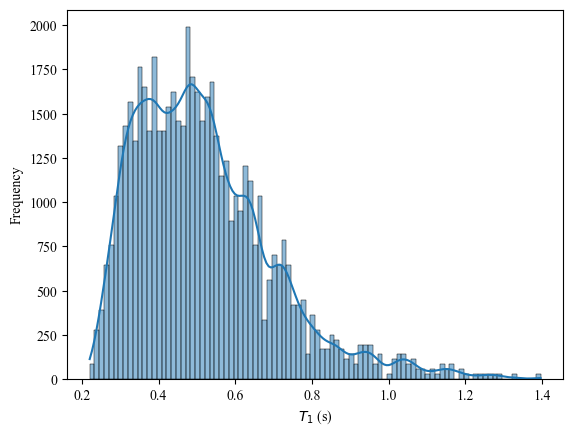

In [4]:
sns.histplot(X["T1_(s)"], kde=True)
plt.xlabel(r"$T_{1}$ (s)")
plt.ylabel("Frequency")
# plt.savefig("T1_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

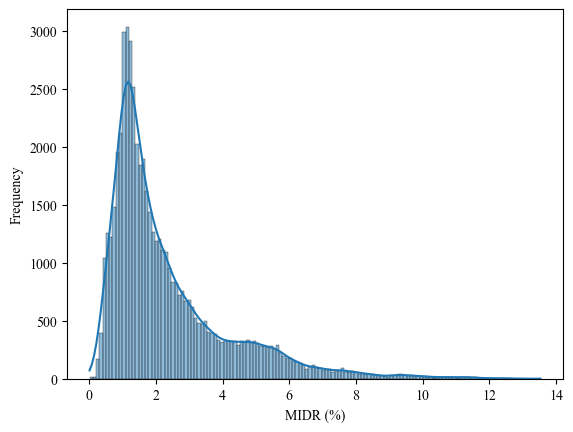

In [5]:
sns.histplot(y, kde=True)
plt.xlabel("MIDR (%)")
plt.ylabel("Frequency")
# plt.savefig("MIDR_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

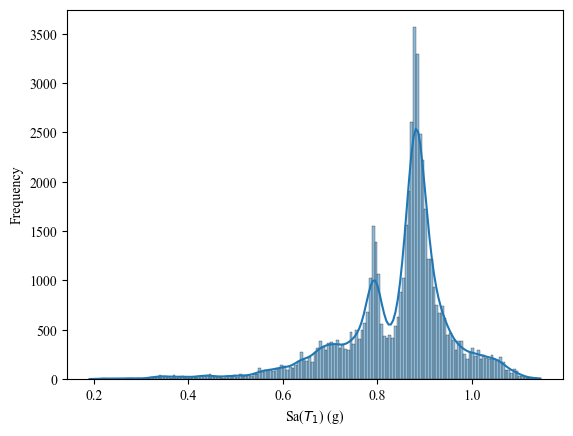

In [9]:
sns.histplot(X["Sa(T1)_(g)"], kde=True)
plt.xlabel("Sa($T_{1}$) (g)")
plt.ylabel("Frequency")
plt.savefig("Sa(T1)_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
corr_matrix = df.corr()
target_corr = corr_matrix[y.name].sort_values(ascending=False)

print("Top 10 Positive Correlations with Target:")
print(target_corr[1:11])  # skip self-correlation
print("\nTop 10 Negative Correlations with Target:")
print(target_corr[-10:])

In [ ]:
feature_variances = X.var().sort_values(ascending=False)
feature_std = X.std().sort_values(ascending=False)

print("Top 5 Features by Variance:")
print(feature_variances.head())
print("\nTop 5 Features by Standard Deviation:")
print(feature_std.head())

In [ ]:
# Define number of columns
n_cols = 4
n_features = X.shape[1]
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

# Label map
label_map = {
    "Tm_(sec)": r"$T_m$ (s)",
    "A_RMS_(g)": r"$A_\mathrm{RMS}$ (g)",
    "V_RMS_(cm/sec)": r"$V_\mathrm{RMS}$ (cm/s)",
    "Tpred_(sec)": r"$T_\mathrm{pred}$ (s)",
    "Sa(T1)_(g)": r"$S_a(T_{1})$ (g)",
    "T1_(s)": r"$T_{1}$ (s)",
    "ρ": r"$\rho$",
    "Ab_(m2)": r"$A_b$ ($\mathrm{m}^2$)",
    "Ac_(m2)": r"$A_c$ ($\mathrm{m}^2$)",
    "Ap_(m2)": r"$A_p$ ($\mathrm{m}^2$)"
}

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Flatten in case it's a 2D array

# Plot each feature
for i, col in enumerate(X.columns):
    ax = axes[i]
    X[col].hist(bins=30, ax=ax)
    ax.set_title(label_map.get(col, col.replace("_", " ")))
    ax.grid(True, linewidth=0.25)

# Hide any unused axes
for j in range(len(X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("feature_distributions_4col.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
X.hist(bins=30, figsize=(20, 15))

label_map = {
    "Tm_(sec)": r"$T_m$ (s)",
    "A_RMS_(g)": r"$A_\mathrm{RMS}$ (g)",
    "V_RMS_(cm/sec)": r"$V_\mathrm{RMS}$ (cm/s)",
    "Tpred_(sec)": r"$T_\mathrm{pred}$ (s)",
    "Sa(T1)_(g)": r"$S_a(T_{1})$ (g)",
    "T1_(s)": r"$T_{1}$ (s)",
    "ρ": r"$\rho$",
    "Ab_(m2)": r"$A_b$ ($\mathrm{m}^2$)",
    "Ac_(m2)": r"$A_c$ ($\mathrm{m}^2$)",
    "Ap_(m2)": r"$A_p$ ($\mathrm{m}^2$)"
}

for ax, col in zip(plt.gcf().axes, X.columns):
    if col in label_map:
        ax.set_title(label_map[col])
    else:
        ax.set_title(col.replace("_", " "))
    ax.grid(True, linewidth=0.25) 
plt.tight_layout()
plt.savefig("feature_distributions.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
skewness = X.skew().sort_values(ascending=False)
kurtosis = X.kurtosis().sort_values(ascending=False)

print("Top 5 Most Skewed Features:")
print(skewness.head())
print("\nTop 5 Highest Kurtosis:")
print(kurtosis.head())

In [ ]:
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((column < (Q1 - 1.5 * IQR)) | (column > (Q3 + 1.5 * IQR)))
    return outliers.sum()

outlier_counts = X.apply(detect_outliers_iqr).sort_values(ascending=False)
print("Features with Most Outliers:")
print(outlier_counts[outlier_counts > 0])